# Forward Kinematics — 2-DOF Planar Robotic Arm

This notebook establishes the mathematical foundation of the 2-DOF robotic arm developed in this project.

The objective is to implement **forward kinematics**, which determines the Cartesian position of the robot's end effector from its joint angles and link lengths.

The mathematical model developed here will later be used for:

* Robot animation and simulation
* Automatic configuration-space exploration
* Dataset generation
* Workspace visualization
* Neural-network-based inverse kinematics
* Motion planning
* Physical robot implementation


## 1. Objective

The first stage of the project is to construct a mathematical representation of a two-link planar robotic arm.

The robot has:

* Two rotational joints
* Two rigid links
* A fixed base
* A 2D Cartesian workspace

The main relationship we want to establish is:

$$
(\theta_1,\theta_2) \rightarrow (x,y)
$$

where:

* \(\theta_1\) is the first joint angle
* \(\theta_2\) is the second joint angle
* \(x,y\) represent the end-effector position
* \(L_1,L_2\) represent the link lengths

This relationship is known as **forward kinematics**.


## 2. Robot Configuration

The initial robot is defined as a 2-DOF planar manipulator.

### Physical parameters

| Parameter             |     Value |
| --------------------- | --------: |
| Link 1 length \(L_1\) |     10 cm |
| Link 2 length \(L_2\) |     10 cm |
| Base position         | \((0,0)\) |
| Number of joints      |         2 |
| Workspace             |        2D |

The base of the robot is fixed at the origin:

$$
O=(0,0)
$$

Both joints are rotational.


## 3. Coordinate System and Angle Convention

A Cartesian coordinate system is defined with the robot's base at the origin.

The positive \(x\)-axis points to the right and the positive \(y\)-axis points upward.

Angles are measured counter-clockwise from the positive \(x\)-axis.

Therefore:

$$
\theta=0^\circ
$$

corresponds to a horizontal link pointing to the right, while:

$$
\theta=90^\circ
$$

corresponds to a vertical link pointing upward.

The second joint angle \(\theta_2\) is defined **relative to the first link**. Therefore, the absolute orientation of Link 2 is:

$$
\theta_1+\theta_2
$$


## 4. Forward Kinematics

For Link 1, the position of Joint 2 is:

$$
x_1=L_1\cos(\theta_1)
$$

$$
y_1=L_1\sin(\theta_1)
$$

For Link 2, its absolute orientation is:

$$
\theta_1+\theta_2
$$

Therefore, the end-effector position is:

$$
\boxed{x=L_1\cos(\theta_1)+L_2\cos(\theta_1+\theta_2)}
$$

$$
\boxed{y=L_1\sin(\theta_1)+L_2\sin(\theta_1+\theta_2)}
$$

These equations form the mathematical core of the robot model and will be reused throughout the project.


### 1.Define the Robot

In [1]:
#assign the lengths of the two links
import numpy as np
L1 = 10.0  # cm
L2 = 10.0  # cm

In [19]:
#define the forward kinematics function
def forward_kinematics(theta1, theta2):
    #convert angles to radians
    theta1 = np.radians(theta1)  # degrees to radians
    theta2 = np.radians(theta2)  # degrees to radians

    #calculate the positions of the base, first joint, and end effector
    x0, y0 = 0.0, 0.0
    x1 = np.round(L1 * np.cos(theta1), 10)
    y1 = np.round(L1 * np.sin(theta1), 10)

    x2 = np.round(x1 + L2 * np.cos(theta1 + theta2), 10)
    y2 = np.round(y1 + L2 * np.sin(theta1 + theta2), 10)

    return (x0, y0), (x1, y1), (x2, y2)


In [16]:
#test the function with some example angles - vertical position
theta1 = 90  # degrees
theta2 = 0 # degrees

(x0, y0), (x1, y1), (x2, y2) = forward_kinematics(theta1, theta2)
print(f"Base: x = {x0:.2f} cm, y = {y0:.2f} cm")
print(f"First joint: x = {x1:.2f} cm, y = {y1:.2f} cm")
print(f"End effector: x = {x2:.2f} cm, y = {y2:.2f} cm")



Base: x = 0.00 cm, y = 0.00 cm
First joint: x = 0.00 cm, y = 10.00 cm
End effector: x = 0.00 cm, y = 20.00 cm


### For better mathematical model we will create a class Robot Object to change the shape of the robot hand when needed

In [2]:
# create Robot Arm class
class RobotArm2DOF:
    def __init__(self, L1, L2):
        self.L1 = L1
        self.L2 = L2
        theta1_limits=(-90, 180),
        theta2_limits=(-120, 120)

    def forward_kinematics(self, theta1, theta2):
        #convert angles to radians
        theta1 = np.radians(theta1)  # degrees to radians
        theta2 = np.radians(theta2)  # degrees to radians

        #calculate the positions of the base, first joint, and end effector
        x0, y0 = 0.0, 0.0
        x1 = np.round(self.L1 * np.cos(theta1), 10)
        y1 = np.round(self.L1 * np.sin(theta1), 10)

        x2 = np.round(x1 + self.L2 * np.cos(theta1 + theta2), 10)
        y2 = np.round(y1 + self.L2 * np.sin(theta1 + theta2), 10)

        return (x0, y0), (x1, y1), (x2, y2)


In [4]:
# assign object of RobotArm2DOF class
robot = RobotArm2DOF(10, 10) # lengths of the two links

origin, joint2, end_effector = robot.forward_kinematics(90, 0)
print(f"Origin: ({origin[0]:g}, {origin[1]:g})")
print(f"Joint 2: ({joint2[0]:g}, {joint2[1]:g})")
print(f"End Effector: ({end_effector[0]:g}, {end_effector[1]:g})")



Origin: (0, 0)
Joint 2: (0, 10)
End Effector: (0, 20)


### 1.2 add forward kinematics validation tests

Before we move on, we will test these five configurations:

|   θ₁ |   θ₂ | Expected idea          |
| ---: | ---: | ---------------------- |
|   0° |   0° | Fully horizontal right |
|  90° |   0° | Fully vertical         |
|  90° | -90° | L-shaped               |
|  45° |  45° | Bent upward/right      |
| 180° |   0° | Fully horizontal left  |


In [21]:
configurations = [
    (0, 0, "Fully horizontal right"),
    (90, 0, "Fully vertical"),
    (90, -90, "L-shaped"),
    (45, 45, "Bent upward/right"),
    (180, 0, "Fully horizontal left"),
]

print("| Configuration | theta1 | theta2 | Origin | Joint 2 | End Effector |")
print("|---|---:|---:|---|---|---|")

for configuration_number, (theta1, theta2, description) in enumerate(configurations, start=1):
    origin, joint2, end_effector = robot.forward_kinematics(theta1, theta2)
    print(
        f"| {configuration_number}. {description} | {theta1}° | {theta2}° | "
        f"({origin[0]:.2f}, {origin[1]:.2f}) | "
        f"({joint2[0]:.2f}, {joint2[1]:.2f}) | "
        f"({end_effector[0]:.2f}, {end_effector[1]:.2f}) |"
    )


| Configuration | theta1 | theta2 | Origin | Joint 2 | End Effector |
|---|---:|---:|---|---|---|
| 1. Fully horizontal right | 0° | 0° | (0.00, 0.00) | (10.00, 0.00) | (20.00, 0.00) |
| 2. Fully vertical | 90° | 0° | (0.00, 0.00) | (0.00, 10.00) | (0.00, 20.00) |
| 3. L-shaped | 90° | -90° | (0.00, 0.00) | (0.00, 10.00) | (10.00, 10.00) |
| 4. Bent upward/right | 45° | 45° | (0.00, 0.00) | (7.07, 7.07) | (7.07, 17.07) |
| 5. Fully horizontal left | 180° | 0° | (0.00, 0.00) | (-10.00, 0.00) | (-20.00, 0.00) |


## Forward Kinematics Validation Results

| Configuration | theta1 | theta2 | Origin | Joint 2 | End Effector |
|---|---:|---:|---|---|---|
| 1. Fully horizontal right | 0° | 0° | (0.00, 0.00) | (10.00, 0.00) | (20.00, 0.00) |
| 2. Fully vertical | 90° | 0° | (0.00, 0.00) | (0.00, 10.00) | (0.00, 20.00) |
| 3. L-shaped | 90° | -90° | (0.00, 0.00) | (0.00, 10.00) | (10.00, 10.00) |
| 4. Bent upward/right | 45° | 45° | (0.00, 0.00) | (7.07, 7.07) | (7.07, 17.07) |
| 5. Fully horizontal left | 180° | 0° | (0.00, 0.00) | (-10.00, 0.00) | (-20.00, 0.00) |


## 2. Animate the mathematical robot

#### 2.1 Static Plot of the Robot

The `plot_robot_configuration` function below separates visualization from the forward-kinematics calculation. It accepts any two joint angles, uses the validated `robot.forward_kinematics` method to calculate the three points, and draws the two links between them.

The function also keeps equal scaling on both axes so the arm keeps its physical proportions. It returns the Matplotlib figure and axes, which will be useful later when we add animation.

To visualize another configuration, call the function with different values for `theta1` and `theta2`, for example:

```python
plot_robot_configuration(robot, 45, 45)
```


In [27]:
# Import Matplotlib's plotting interface for creating the robot figure.
import matplotlib.pyplot as plt


# Define a reusable function for visualizing any pair of joint angles.
def plot_robot_configuration(robot, theta1, theta2, ax=None):
    # Explain what the function accepts and what it returns.
    """Plot one robot configuration and return its Matplotlib figure and axes."""

    # Calculate the origin, Joint 2, and end-effector positions with the validated model.
    origin, joint2, end_effector = robot.forward_kinematics(theta1, theta2)

    # Store the points in drawing order: base, first joint, and end effector.
    points = [origin, joint2, end_effector]

    # Split the coordinate pairs into separate x and y sequences for plotting.
    x_coordinates, y_coordinates = zip(*points)

    # Create a new square figure when the caller does not provide existing axes.
    if ax is None:
        # Create a 6-by-6 inch figure and one set of axes.
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        # Reuse the supplied axes and its existing figure.
        fig = ax.figure

    # Draw both robot links and mark all three robot points.
    ax.plot(
        # Use the point coordinates to connect the two links.
        x_coordinates,
        y_coordinates,
        # Use circles at the joints and a line between consecutive points.
        "o-",
        # Set the link color and line thickness.
        color="tab:blue",
        linewidth=8,
        # Set the size of the point markers.
        markersize=8,
        # Add the links to the legend.
        label="Robot arm",
    )

    # Highlight the fixed base in green.
    ax.scatter(*origin, color="green", s=100, zorder=3, label="Origin")

    # Highlight Joint 2 in orange.
    ax.scatter(*joint2, color="orange", s=100, zorder=3, label="Joint 2")

    # Highlight the end effector in red.
    ax.scatter(*end_effector, color="red", s=100, zorder=3, label="End effector")

    # Add readable labels next to each point.
    ax.annotate("Origin", origin, xytext=(8, 8), textcoords="offset points")
    ax.annotate("Joint 2", joint2, xytext=(8, 8), textcoords="offset points")
    ax.annotate("End effector", end_effector, xytext=(8, 8), textcoords="offset points")

    # Calculate the maximum distance the arm can reach from the origin.
    maximum_reach = robot.L1 + robot.L2

    # Add space around the reachable area so markers and labels are visible.
    padding = max(2, maximum_reach * 0.1)

    # Set equal x and y limits based on the robot's maximum reach.
    ax.set_xlim(-maximum_reach - padding, maximum_reach + padding)
    ax.set_ylim(-maximum_reach - padding, maximum_reach + padding)

    # Keep the same scale on both axes so the arm is not visually distorted.
    ax.set_aspect("equal", adjustable="box")

    # Add axis labels and a title containing the selected joint angles.
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
    ax.set_title(f"2-DOF Robot Arm: theta1 = {theta1}°, theta2 = {theta2}°")

    # Add a grid to make the coordinates easier to read.
    ax.grid(True)

    # Display the labels for the arm and its three important points.
    ax.legend()

    # Return the figure and axes for later customization or animation.
    return fig, ax



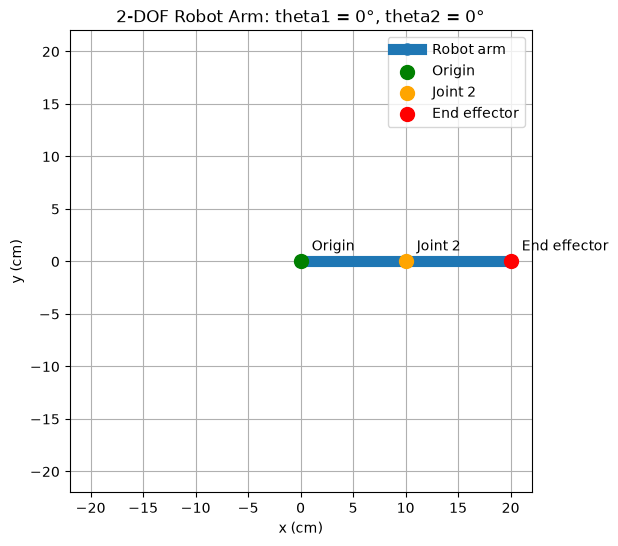

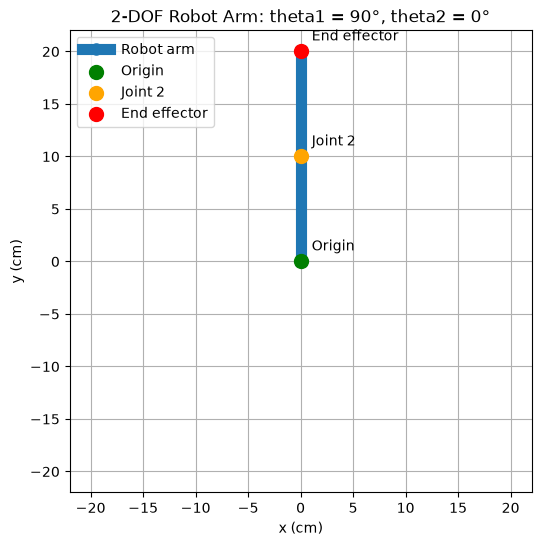

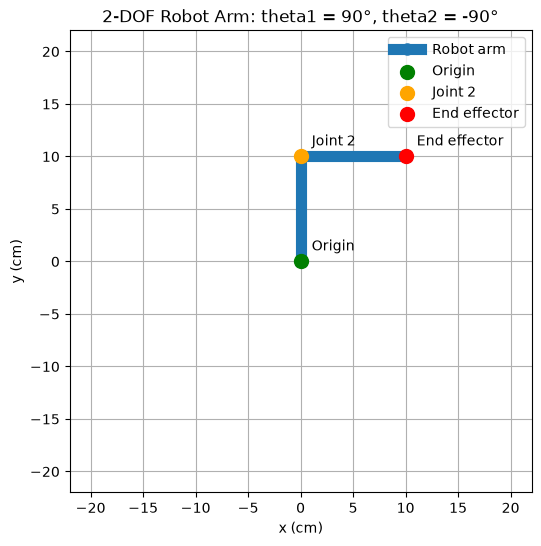

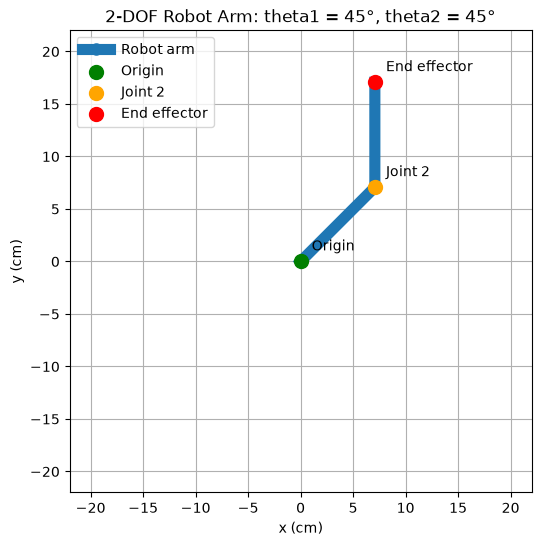

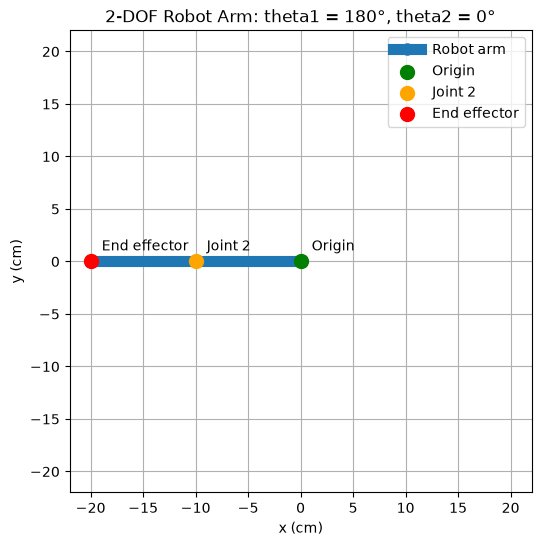

In [29]:
# visualize all five validated configurations:
for theta1, theta2, _ in configurations:
  plot_robot_configuration(robot, theta1, theta2)